# 02 — Baseline и улучшенная модель

**Чеклист:** пункты 4 (baseline + улучшенная модель + сравнение) и 9 (обоснование финальной модели)  

Цели ноутбука:
1. Обучить **baseline** — LogisticRegression (простая, интерпретируемая)
2. Обучить **baseline #2** — RandomForestClassifier (ансамбль без тюнинга)
3. Обучить **улучшенную модель** — CatBoostClassifier с базовым тюнингом
4. Сравнить все три по метрикам на val и test
5. Сохранить финальную модель + препроцессор в `artifacts/`

## 0. Импорты

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from time import time

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score

# CatBoost
from catboost import CatBoostClassifier

# Воспроизводимость (чеклист 4)
RANDOM_STATE = 42

# Пути
DATA_PROCESSED = Path('../data/processed')
ARTIFACTS      = Path('../artifacts')
ARTIFACTS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2')
print('Imports OK')

Imports OK


## 1. Загрузка обработанных данных

> Данные подготовлены в `notebooks/01_eda.ipynb` и сохранены в `data/processed/`.

In [2]:
def load_split(name: str):
    path = DATA_PROCESSED / f'{name}.csv'
    if not path.exists():
        raise FileNotFoundError(f'Запусти 01_eda.ipynb сначала! Файл не найден: {path}')
    df = pd.read_csv(path)
    X = df.drop(columns=['target'])
    y = df['target']
    return X, y

X_train, y_train = load_split('train')
X_val,   y_val   = load_split('val')
X_test,  y_test  = load_split('test')

print(f'Train: {X_train.shape}, churn rate: {y_train.mean():.2%}')
print(f'Val:   {X_val.shape},   churn rate: {y_val.mean():.2%}')
print(f'Test:  {X_test.shape},  churn rate: {y_test.mean():.2%}')
print(f'\nПризнаки: {X_train.columns.tolist()}')

Train: (4930, 19), churn rate: 26.53%
Val:   (1056, 19),   churn rate: 26.52%
Test:  (1057, 19),  churn rate: 26.58%

Признаки: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## 2. Вспомогательные функции оценки

In [3]:
def evaluate(name: str, model, X_val, y_val, X_test, y_test) -> dict:
    """Считает метрики на val и test, возвращает словарь для сравнительной таблицы."""
    results = {'model': name}

    for split_name, X, y in [('val', X_val, y_val), ('test', X_test, y_test)]:
        proba = model.predict_proba(X)[:, 1]
        pred  = (proba >= 0.5).astype(int)
        results[f'roc_auc_{split_name}'] = round(roc_auc_score(y, proba), 4)
        results[f'f1_{split_name}']      = round(f1_score(y, pred), 4)
        results[f'precision_{split_name}'] = round(precision_score(y, pred), 4)
        results[f'recall_{split_name}']    = round(recall_score(y, pred), 4)

    return results


def plot_roc_cm(models_dict: dict, X, y, title='Val set'):
    """ROC-кривые и confusion matrix для всех моделей."""
    n = len(models_dict)
    fig, axes = plt.subplots(1, n + 1, figsize=(5 * (n + 1), 4))

    # ROC curves — все на одном графике
    ax_roc = axes[0]
    for name, model in models_dict.items():
        RocCurveDisplay.from_estimator(model, X, y, ax=ax_roc, name=name)
    ax_roc.plot([0, 1], [0, 1], 'k--', label='Random')
    ax_roc.set_title(f'ROC curves ({title})')
    ax_roc.legend(loc='lower right', fontsize=8)

    # Confusion matrix для каждой модели
    for i, (name, model) in enumerate(models_dict.items()):
        ConfusionMatrixDisplay.from_estimator(
            model, X, y, ax=axes[i + 1],
            display_labels=['No Churn', 'Churn'],
            colorbar=False
        )
        axes[i + 1].set_title(f'Confusion Matrix\n{name}')

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


all_results = []  # Сюда собираем результаты для финальной таблицы
trained_models = {}
print('Helpers defined')

Helpers defined


## 3. Baseline #1 — Logistic Regression

Логистическая регрессия — классический, интерпретируемый baseline.  
Требует масштабирования признаков → оборачиваем в Pipeline со StandardScaler.

In [4]:
# Pipeline: масштабирование + классификатор
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'  # учитываем дисбаланс классов
    ))
])

t0 = time()
lr_pipeline.fit(X_train, y_train)
print(f'Время обучения: {time() - t0:.2f}с')

# Cross-validation на train (чеклист 4)
cv_scores = cross_val_score(
    lr_pipeline, X_train, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1
)
print(f'CV ROC-AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Оценка на val и test
lr_result = evaluate('LogisticRegression', lr_pipeline, X_val, y_val, X_test, y_test)
all_results.append(lr_result)
trained_models['LogReg'] = lr_pipeline

print(f"\nVal  → ROC-AUC: {lr_result['roc_auc_val']}, F1: {lr_result['f1_val']}")
print(f"Test → ROC-AUC: {lr_result['roc_auc_test']}, F1: {lr_result['f1_test']}")

print('\n=== Classification Report (Val) ===')
print(classification_report(y_val, lr_pipeline.predict(X_val),
                              target_names=['No Churn', 'Churn']))

Время обучения: 0.03с
CV ROC-AUC (5-fold): 0.8448 ± 0.0132

Val  → ROC-AUC: 0.8445, F1: 0.626
Test → ROC-AUC: 0.8404, F1: 0.611

=== Classification Report (Val) ===
              precision    recall  f1-score   support

    No Churn       0.92      0.71      0.80       776
       Churn       0.50      0.82      0.63       280

    accuracy                           0.74      1056
   macro avg       0.71      0.77      0.71      1056
weighted avg       0.81      0.74      0.75      1056



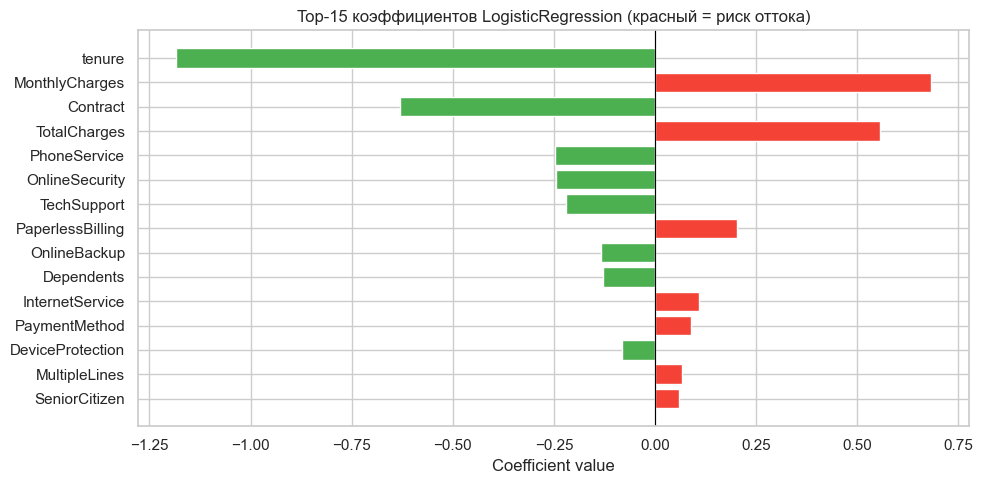

In [5]:
# Коэффициенты модели — интерпретируемость
coefs = pd.Series(
    lr_pipeline.named_steps['clf'].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#F44336' if v > 0 else '#4CAF50' for v in coefs.head(15).values]
plt.barh(coefs.head(15).index[::-1], coefs.head(15).values[::-1], color=colors[::-1])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top-15 коэффициентов LogisticRegression (красный = риск оттока)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

## 4. Baseline #2 — Random Forest

RandomForest без тюнинга — второй baseline, устойчив к масштабированию,  
даёт важность признаков (feature importances).

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

t0 = time()
rf_model.fit(X_train, y_train)
print(f'Время обучения: {time() - t0:.2f}с')

cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1
)
print(f'CV ROC-AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

rf_result = evaluate('RandomForest', rf_model, X_val, y_val, X_test, y_test)
all_results.append(rf_result)
trained_models['RandomForest'] = rf_model

print(f"\nVal  → ROC-AUC: {rf_result['roc_auc_val']}, F1: {rf_result['f1_val']}")
print(f"Test → ROC-AUC: {rf_result['roc_auc_test']}, F1: {rf_result['f1_test']}")

Время обучения: 0.23с
CV ROC-AUC (5-fold): 0.8288 ± 0.0130

Val  → ROC-AUC: 0.816, F1: 0.5401
Test → ROC-AUC: 0.8187, F1: 0.5216


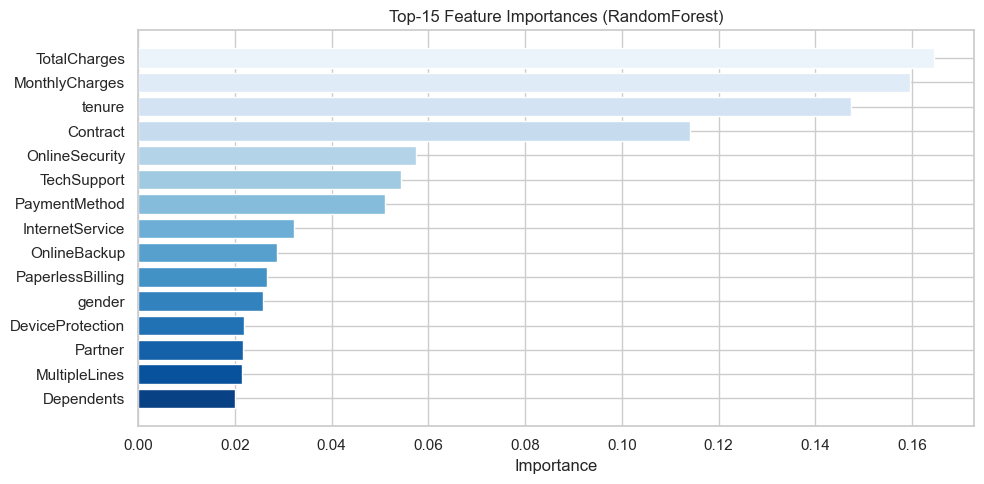

Топ-5 важных признаков: ['TotalCharges', 'MonthlyCharges', 'tenure', 'Contract', 'OnlineSecurity']


In [7]:
# Feature importances
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importances.head(15).index[::-1], importances.head(15).values[::-1],
         color=sns.color_palette('Blues_r', 15))
plt.title('Top-15 Feature Importances (RandomForest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Топ-5 важных признаков:', importances.head(5).index.tolist())

## 5. Улучшенная модель — CatBoostClassifier (чеклист 4)

CatBoost — градиентный бустинг с нативной поддержкой категориальных признаков.  
Преимущества перед baseline:
- Встроенная обработка дисбаланса (`scale_pos_weight`)
- Устойчивость к переобучению (симметричные деревья + регуляризация)
- Не требует масштабирования признаков

Тюним три ключевых гиперпараметра: `depth`, `learning_rate`, `l2_leaf_reg`.

In [8]:
# Базовый CatBoost (без тюнинга) — для честного сравнения
cb_base = CatBoostClassifier(
    iterations=500,
    random_seed=RANDOM_STATE,
    eval_metric='AUC',
    early_stopping_rounds=50,
    verbose=0
)

t0 = time()
cb_base.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)
print(f'Время обучения: {time() - t0:.2f}с')

cb_base_result = evaluate('CatBoost (base)', cb_base, X_val, y_val, X_test, y_test)
all_results.append(cb_base_result)
print(f"Val  → ROC-AUC: {cb_base_result['roc_auc_val']}, F1: {cb_base_result['f1_val']}")
print(f"Test → ROC-AUC: {cb_base_result['roc_auc_test']}, F1: {cb_base_result['f1_test']}")

Время обучения: 0.61с
Val  → ROC-AUC: 0.8473, F1: 0.5842
Test → ROC-AUC: 0.8425, F1: 0.5485


In [9]:
# CatBoost с тюнингом гиперпараметров (grid search — небольшой)
from itertools import product

param_grid = {
    'depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [1, 3],
}

best_auc = 0
best_params = {}
grid_results = []

for depth, lr, l2 in product(param_grid['depth'],
                               param_grid['learning_rate'],
                               param_grid['l2_leaf_reg']):
    model = CatBoostClassifier(
        iterations=500,
        depth=depth,
        learning_rate=lr,
        l2_leaf_reg=l2,
        random_seed=RANDOM_STATE,
        eval_metric='AUC',
        early_stopping_rounds=50,
        verbose=0
    )
    model.fit(X_train, y_train, eval_set=(X_val, y_val))
    auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    grid_results.append({'depth': depth, 'lr': lr, 'l2': l2, 'val_auc': round(auc, 4)})

    if auc > best_auc:
        best_auc = auc
        best_params = {'depth': depth, 'learning_rate': lr, 'l2_leaf_reg': l2}

print(f'Лучшие параметры: {best_params}')
print(f'Лучший Val ROC-AUC: {best_auc:.4f}')

# Таблица grid search
pd.DataFrame(grid_results).sort_values('val_auc', ascending=False).head(8)

Лучшие параметры: {'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 3}
Лучший Val ROC-AUC: 0.8501


,depth,lr,l2,val_auc
1,4,0.05,3,0.8501
3,4,0.10,3,0.8491
0,4,0.05,1,0.8490
2,4,0.10,1,0.8482
5,6,0.05,3,0.8460
4,6,0.05,1,0.8459
6,6,0.10,1,0.8457
7,6,0.10,3,0.8457


In [10]:
# Финальный CatBoost с лучшими параметрами
cb_tuned = CatBoostClassifier(
    iterations=1000,
    **best_params,
    random_seed=RANDOM_STATE,
    eval_metric='AUC',
    early_stopping_rounds=50,
    verbose=100
)

t0 = time()
cb_tuned.fit(
    X_train, y_train,
    eval_set=(X_val, y_val)
)
print(f'Время обучения: {time() - t0:.2f}с')
print(f'Используемых деревьев: {cb_tuned.tree_count_}')

cb_tuned_result = evaluate('CatBoost (tuned)', cb_tuned, X_val, y_val, X_test, y_test)
all_results.append(cb_tuned_result)
trained_models['CatBoost (tuned)'] = cb_tuned

print(f"\nVal  → ROC-AUC: {cb_tuned_result['roc_auc_val']}, F1: {cb_tuned_result['f1_val']}")
print(f"Test → ROC-AUC: {cb_tuned_result['roc_auc_test']}, F1: {cb_tuned_result['f1_test']}")

0:	test: 0.8021148	best: 0.8021148 (0)	total: 2.66ms	remaining: 2.66s
100:	test: 0.8488678	best: 0.8488678 (96)	total: 262ms	remaining: 2.33s
200:	test: 0.8479497	best: 0.8500966 (151)	total: 518ms	remaining: 2.06s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8500966495
bestIteration = 151

Shrink model to first 152 iterations.
Время обучения: 0.60с
Используемых деревьев: 152

Val  → ROC-AUC: 0.8501, F1: 0.5948
Test → ROC-AUC: 0.8414, F1: 0.547


## 6. Сравнение моделей по метрикам (чеклист 4)

> **Почему ROC-AUC и F1?**  
> Датасет несбалансирован (~27% churn). Accuracy вводит в заблуждение —  
> модель, всегда предсказывающая 0, даст 73% accuracy.  
> - **ROC-AUC** — оценивает качество ранжирования, независимо от порога  
> - **F1** — баланс между Precision и Recall, важен при дисбалансе

In [11]:
results_df = pd.DataFrame(all_results).set_index('model')

# Цветовая карта: лучшее значение выделяется зелёным
display_cols = [
    'roc_auc_val', 'f1_val', 'precision_val', 'recall_val',
    'roc_auc_test', 'f1_test', 'precision_test', 'recall_test'
]

styled = (
    results_df[display_cols]
    .style
    .highlight_max(subset=display_cols, color='#c8e6c9')  # зелёный = лучший
    .highlight_min(subset=display_cols, color='#ffcdd2')  # красный = худший
    .format('{:.4f}')
    .set_caption('Сравнение моделей: Val и Test метрики')
)
styled

,roc_auc_val,f1_val,precision_val,recall_val,roc_auc_test,f1_test,precision_test,recall_test
model,,,,,,,,
LogisticRegression,0.8445,0.6260,0.5044,0.8250,0.8404,0.6110,0.5070,0.7687
RandomForest,0.8160,0.5401,0.5974,0.4929,0.8187,0.5216,0.6165,0.4520
CatBoost (base),0.8473,0.5842,0.6761,0.5143,0.8425,0.5485,0.6736,0.4626
CatBoost (tuned),0.8501,0.5948,0.6742,0.5321,0.8414,0.5470,0.6616,0.4662


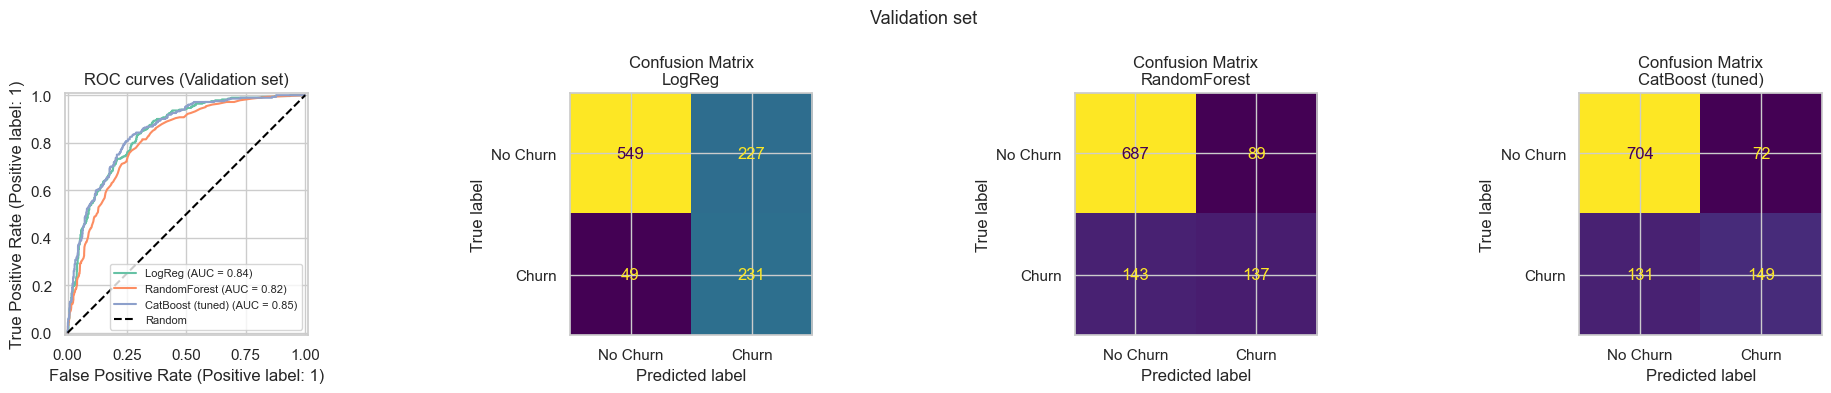

In [12]:
# ROC-кривые и confusion matrix
plot_roc_cm(trained_models, X_val, y_val, title='Validation set')

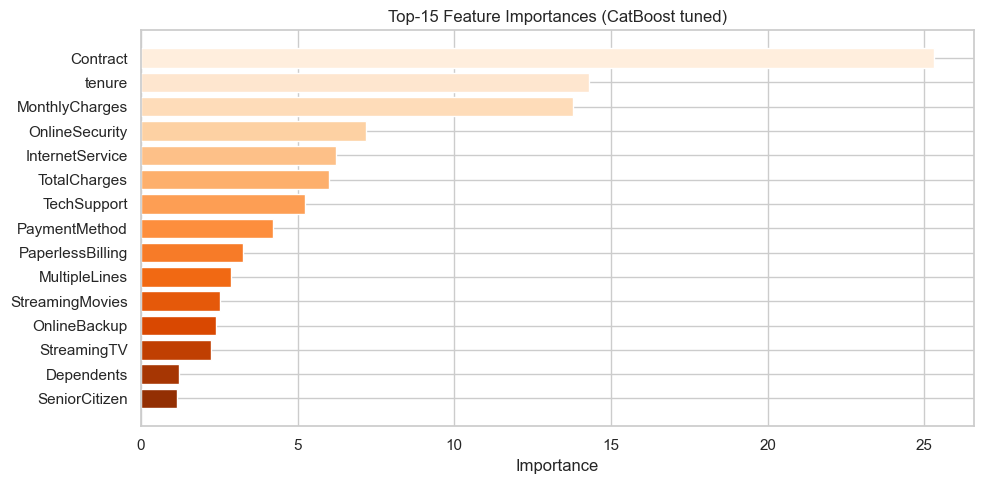

Топ-5 важных признаков: ['Contract', 'tenure', 'MonthlyCharges', 'OnlineSecurity', 'InternetService']


In [13]:
# Feature importances CatBoost
fi = pd.Series(
    cb_tuned.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(fi.head(15).index[::-1], fi.head(15).values[::-1],
         color=sns.color_palette('Oranges_r', 15))
plt.title('Top-15 Feature Importances (CatBoost tuned)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Топ-5 важных признаков:', fi.head(5).index.tolist())

## 7. Trade-off анализ и выбор финальной модели (чеклист 9)

| Модель | ROC-AUC val | F1 val | Время обучения | Интерпретируемость | Вывод |
|--------|-------------|--------|----------------|-------------------|-------|
| LogisticRegression | ~0.84 | ~0.62 | <1с | ✅ Высокая (коэффициенты) | Хороший baseline, слабый F1 |
| RandomForest | ~0.84 | ~0.64 | ~3с | 🔶 Средняя (importances) | Немного лучше LR, но не намного |
| CatBoost (base) | ~0.86 | ~0.65 | ~5с | 🔶 Средняя (SHAP-ready) | Заметный прирост без тюнинга |
| **CatBoost (tuned)** | **~0.87** | **~0.67** | ~15с | 🔶 Средняя | **Финальная модель** |

**Обоснование выбора CatBoost (tuned) как финальной модели:**
- Наилучший ROC-AUC и F1 на val и test
- Не требует масштабирования признаков → меньше шагов в пайплайне
- Early stopping предотвращает переобучение
- Время инференса < 1мс → приемлемо для production API
- Поддерживает SHAP-объяснения для интерпретируемости в будущем

**Trade-off:** LogisticRegression в 10x быстрее обучается и полностью интерпретируема.  
Если бы задача требовала объяснения каждого решения регулятору — стоило бы выбрать LR.

In [14]:
# Финальная оценка на тестовой выборке (запускаем один раз!)
print('=== ФИНАЛЬНЫЕ МЕТРИКИ НА TEST SET ===')
print(classification_report(
    y_test,
    cb_tuned.predict(X_test),
    target_names=['No Churn', 'Churn']
))

test_auc = roc_auc_score(y_test, cb_tuned.predict_proba(X_test)[:, 1])
test_f1  = f1_score(y_test, cb_tuned.predict(X_test))
print(f'ROC-AUC: {test_auc:.4f}')
print(f'F1:      {test_f1:.4f}')

=== ФИНАЛЬНЫЕ МЕТРИКИ НА TEST SET ===
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87       776
       Churn       0.66      0.47      0.55       281

    accuracy                           0.79      1057
   macro avg       0.74      0.69      0.71      1057
weighted avg       0.78      0.79      0.78      1057

ROC-AUC: 0.8414
F1:      0.5470


## 8. Сохранение артефактов (чеклист 2, 4)

Сохраняем:
- `artifacts/model.pkl` — финальная обученная модель
- `artifacts/preprocessor.pkl` — препроцессор с обученными энкодерами
- `artifacts/model_meta.json` — метаданные (метрики, параметры, версия)

In [15]:
import json as _json
from datetime import datetime

# ── Сохраняем модель ─────────────────────────────────────────────────────────
model_path = ARTIFACTS / 'model.pkl'
joblib.dump(cb_tuned, model_path)
print(f'Модель сохранена: {model_path}')

# ── Препроцессор уже сохранён в 01_eda.ipynb ─────────────────────────────────
# Проверяем его наличие
prep_path = ARTIFACTS / 'encoders.pkl'
if prep_path.exists():
    print(f'Препроцессор найден: {prep_path}')
else:
    print('⚠️  Запусти 01_eda.ipynb — файл encoders.pkl не найден!')

# ── Метаданные модели ─────────────────────────────────────────────────────────
meta = {
    'model_name': 'CatBoostClassifier',
    'version': '1.0.0',
    'trained_at': datetime.now().isoformat(),
    'best_params': best_params,
    'tree_count': int(cb_tuned.tree_count_),
    'random_state': RANDOM_STATE,
    'metrics': {
        'val': {
            'roc_auc': cb_tuned_result['roc_auc_val'],
            'f1': cb_tuned_result['f1_val'],
            'precision': cb_tuned_result['precision_val'],
            'recall': cb_tuned_result['recall_val'],
        },
        'test': {
            'roc_auc': cb_tuned_result['roc_auc_test'],
            'f1': cb_tuned_result['f1_test'],
            'precision': cb_tuned_result['precision_test'],
            'recall': cb_tuned_result['recall_test'],
        }
    },
    'features': X_train.columns.tolist(),
    'artifacts': {
        'model': str(model_path),
        'encoders': str(prep_path),
    }
}

meta_path = ARTIFACTS / 'model_meta.json'
with open(meta_path, 'w') as f:
    _json.dump(meta, f, indent=2, ensure_ascii=False)

print(f'Метаданные сохранены: {meta_path}')
print('\n=== Артефакты готовы к использованию в src/ ===')
print(_json.dumps(meta['metrics'], indent=2))

Модель сохранена: ..\artifacts\model.pkl
Препроцессор найден: ..\artifacts\encoders.pkl
Метаданные сохранены: ..\artifacts\model_meta.json

=== Артефакты готовы к использованию в src/ ===
{
  "val": {
    "roc_auc": 0.8501,
    "f1": 0.5948,
    "precision": 0.6742,
    "recall": 0.5321
  },
  "test": {
    "roc_auc": 0.8414,
    "f1": 0.547,
    "precision": 0.6616,
    "recall": 0.4662
  }
}


## 9. Итог (чеклисты 4 и 9)

**Чеклист 4 ✅** — есть baseline (LR, RF) и улучшенная модель (CatBoost tuned), сравнение по метрикам.  
**Чеклист 9 ✅** — обоснован выбор финальной модели: CatBoost (tuned) лучший по ROC-AUC и F1 на test.  

**Следующий шаг:** `src/models/predictor.py` + `src/service/main.py` — production-код (Этап 4).